# One dimensional dummy problem

## Problem Statement

The model will have diffusion of hydrogen gas and convection with a flow speed that is calculated from the pressure. The battery will be on the domain $\Omega = (0,L)$, where $L$ is the length of the battery. The left boundary will be the inflow of hydrogen gas, and the right boundary will be the outflow of hydrogen gas. Since we now also model the pressure we can assume pure hydrogen gas everywhere, and adjust the gas absorption with its intended pressure dependency. It also assumes constant temperature, and ideal gas law: $p=\rho_g RT$. The model also takes into account viscous dissipation of a poreous medium. It is summarized in the following system of equations:
\begin{equation}
\left\{\begin{aligned}
\rho_g \partial_t v &=-RT\partial_x\rho_g-\rho_g v \partial_x v+\mu\partial_x^2 v -S\\
\partial_t\rho_g&=-\partial_x (\rho_g v)+ \mu_\epsilon\partial_x^2\rho_g-\dot m \\
\partial_t \rho_s &= \dot m 
\end{aligned}\right.
\end{equation}
Where $\rho_g$ is the density of H2 in the air, now seen as a true density, instead of a ratio. $\rho_s$ is the amount of hydrogen in the solid Metal Organic Framework, $v$ is the flow speed, $\mu$ is the viscosity of the gas, and $\mu_\epsilon$ is the diffusion coefficient, this is required numerically to avoid instabilities and oscilations (even when using upwind schemes). The absorption and viscous dissipation are given by:
\begin{align}
    \dot m &= A\log(\frac{p_g}{p_{eq,a}})(\rho_{sat}-\rho_s)\\
    S &= \frac{\mu}{K}v
\end{align}
under IC:
\begin{equation}
\left\{ \begin{aligned}
\rho_g(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}
(the solid doesn't need a boundary condition since it is not really coupled to its surroundings), and BC:
\begin{equation}
\left\{\begin{aligned}
    v(L,t) &= 0\\
\rho_g(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
\end{aligned}\right.
\end{equation}
where we use a steep increase in density at the inlet to simulate a step function, since a discontinuity gives extremely low initial time steps. The BC for the velocity is a no-slip condition at the outlet, and a zero gradient at the inlet. 

We will expand $\rho_g$, $\rho_s$, and $v$ as:
\begin{equation}
    \begin{aligned}
         v(x,t) &= \sum_j v^j(t) \phi^j(x) \\
    \rho_g(x,t) &= \sum_i \rho_{g}^i(t) \phi^i(x) \\
    \rho_s(x,t) &= \sum_i \rho_{s}^i(t) \phi^i(x) \\
    \end{aligned}
\end{equation}
with our solutionvector:

\begin{equation}
    \mathbf u = \begin{pmatrix}
        v^1        \\ \vdots \\ v^{N_2}      \\
        \rho_{g}^1 \\ \vdots \\ \rho_{g}^{N_1} \\ 
        \rho_{s}^1 \\ \vdots \\ \rho_{s}^{N_1} \\ 
    \end{pmatrix}
\end{equation}

we will also need an expansion of the mass transfer term:
\begin{equation}
    \dot m(x,t) = \sum_i \dot m^i(t) \phi^i(x)
\end{equation}
which we will approximate at the terms using our knowledge that on nodes the only non-zero basis function is the one corresponding to that node, so we can approximate the mass transfer term as:
\begin{equation}
    \dot m^i(t) = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### Mathematical Discretizations

If we look at the top part equation and multiply by test functions $\phi^k$, integrate and expand as above, we get:

\begin{equation}
    \sum_j\left(\sum_i\rho_i\int_\Omega \phi^i\phi^j\phi^k\,dx\right)(\partial_t \mathbf{u})
\end{equation}

Which becomes:

\begin{equation}
    M\dot{\mathbf{u}}
\end{equation}

where row $k$ and column $j$ correspond to:

\begin{equation}
    (M_v)_{kj} = \sum_i\rho_i\int \phi^i\phi^j\phi^k\,dx
\end{equation}
I plan on precalculating the integrals into a tensor:

\begin{equation}
    T_{ijk} = \int \phi^i\phi^j\phi^k\,dx
\end{equation}
simplifying:
\begin{equation}
(M_v)_{kj}=\sum_i \rho_iT_{ijk}
\end{equation}

For the RHS of the first equation we get (after integration and multiplying by $\phi^k$) term for term:

\begin{equation}
\begin{aligned}
    -RT\sum_i\left(\int \phi^k\phi^i\,dx\right)\rho_i &= P\mathbf{\rho}\\
    -\mu\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) v_i &= D\mathbf{v} 
    % & \text{negative sign due to integration by parts}
    \\
    -\frac{\mu}{K}\sum_i\left(\int \phi^k\phi^i \, dx \right)v_i&= S \mathbf{v}
\end{aligned}
\end{equation}

For the convection term we have:
\begin{equation}
    C^{v}_j = \int_\Omega \phi^k \rho_g v \partial_x v \, dx
\end{equation}
which we will approximate using a quadrature rule.


Giving us:

\begin{equation}
    M_v(\rho) \dot{\mathbf{v}}=P\mathbf{\rho}+D\mathbf{v}+S\mathbf{v}+C^{v}(\mathbf{v},\mathbf{\rho})
\end{equation}


Now for the conservation of mass equation, the LHS becomes:
\begin{equation}
\sum_i\left(\int\phi^i\phi^k\,dx\right)(\partial_t\rho_i)=M_\rho\dot{\mathbf{u}}
\end{equation}

and the first term in the RHS becomes:
\begin{equation}
    -\int\phi^k\partial_x(\rho v)dx = -\left[ \phi^k\rho v\right]_{x\in\delta\Omega}+\int(\partial_x\phi^k)v \rho\, dx =\mathbf{C}^{\rho_g}(\mathbf{v},\mathbf{\rho})
\end{equation}

The diffusion familiarly becomes:
\begin{equation}
    \mu_\epsilon\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) \rho_i = D_\epsilon \mathbf{\rho}
\end{equation}

The mass transfer term is given by:
\begin{equation}
\begin{aligned}
    \int\phi^k\dot m dx &= \int \phi^k \sum_i \dot m^i(t) \phi^i(x) dx \\
    &= \sum_i \dot m^i(t) \int \phi^k \phi^i dx \\
    &= M_{{\rho_g}} \dot{\mathbf{m}}
\end{aligned}
\end{equation}
where:
\begin{equation}
    \dot{m}^i = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### IMEX Scheme

I want to use a similar IMEX Scheme as I did in section 1.
Previously I had solved one with an IMEX scheme, where all linear parts were taken implicit, and non-linear parts explicit. Having

\begin{equation}
\begin{aligned}
M_v(\rho_g)\dot{v}&=P\rho_g+Dv + Sv + C^{v}(\mathbf{v},\mathbf{\rho})\\
M_{\rho_g}\dot{\rho}_g&=D_\epsilon \rho_g-M_{{\rho_g}}\dot{\mathbf{m}}+C^{\rho_g}(\mathbf{v},\mathbf{\rho})\\
M_{\rho_s}\dot{\rho}_s&=M_{{\rho_g}}\dot{\mathbf{m}}
\end{aligned}
\end{equation}
which can be summarized into:
\begin{equation}
\begin{aligned}
    M(u)\dot{u} &= L[u]+N(u) \\
    N(u) &= C(u)+M_m\begin{pmatrix}
    0 \\ -\dot{\mathbf{m}}(u) \\ \dot{\mathbf{m}}(u)
    \end{pmatrix} \\
    L &= \begin{pmatrix}
    D+S & P & 0 \\
    0 & D_\epsilon & 0 \\
    0 & 0 & 0
    \end{pmatrix} \\
    M_m &= \begin{pmatrix}
    0 & 0 & 0 \\
    0 & M_{{\rho_g}} & 0 \\
    0 & 0 & M_{{\rho_g}}
    \end{pmatrix}\\
    M &= \begin{pmatrix}
    M_v(\rho) & 0 & 0 \\
    0 & M_{\rho_g} & 0 \\
    0 & 0 & M_{\rho_s}
    \end{pmatrix}
\end{aligned} 
\end{equation}

Is it now again posible to IMEX scheme like:

\begin{equation}
\begin{aligned}
M_v(\rho^n)\frac{v^{n+1}-v^n}{\Delta t}&=P\rho^{n+1}+Dv^{n+1} \\
M_{\rho}\frac{\rho^{n+1}-\rho^n}{\Delta t}&=N(\rho^n, v^n)+BF^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
\begin{aligned}
\frac{M_{\rho}}{\Delta t}{\rho^{n+1}}&=N(\rho^n, v^n)+BF^n+\frac{M_{\rho}}{\Delta t}\rho^n \\
\left[\frac{M_v(\rho^n)}{\Delta t}-D\right]v^{n+1}-P\rho^{n+1}&=\frac{M_v(\rho^n)}{\Delta t}v^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
    Au^{n+1}=Bu^n+C
\end{equation}

where:

\begin{equation}
\begin{aligned}
    A(\mathbf{u}^n) &= \begin{pmatrix}
    \frac{M_v(\rho_g^n)}{\Delta t}-D-S & -P & 0 \\ 
    0 & \frac{M_{\rho_g}}{\Delta t}-D_\epsilon & 0 \\
    0 & 0 & \frac{M_{\rho_s}}{\Delta t}
    \end{pmatrix} \\
    B &= \begin{pmatrix}
    \frac{M_{\rho}}{\Delta t} & 0 \\
    0 & \frac{M_v(\rho^n)}{\Delta t}
    \end{pmatrix}\\
    C &= \begin{pmatrix}
        C^{v}(\mathbf{v}^n,\boldsymbol{\rho}^n) \\ C^{\rho_g}(\mathbf{v}^n,\boldsymbol{\rho}^n) \\0 
    \end{pmatrix}\\
    (M_{\rho})_{ij}&=\int \phi^i\phi^j\,dx \\
    P_{ij} &= -RT\int\phi^i\partial_x\phi^j\,dx \\
    D_{ij} &= -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx\\
    (M_v(\rho^n))_{kj}&=\sum_i\rho_i T_{kij} \\
    T_{ijk} &= \int \phi^i\phi^j\phi^k\,dx\\
    (N(\rho^n, v^n))_k&=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx\\
\end{aligned}
\end{equation}

In [1]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra

## Definitions

In [2]:
# Time integration parameters
dt = 1e-4
dt_save = 1e-1
T1 = 10.0;

save_every = Int(round(dt_save / dt))  # = 100 steps
nsteps = Int(round(T1 / dt_save))

# Constants
R = 1.0;        # ideal gas constant - should be 8.314 J/(mol*K)
T = 1.0;        # temperature
μ = 1.0;        # dynamic viscosity
μ_ϵ = 0.001;    # artificial diffusion coefficient

MA = 1.0;       # mass transfer coefficient
rho_sat = 1.0;  # saturation density
p_eqa = 1.0;    # equilibrium pressure
K = 1.0;        # permeability

name = "c. one dimensional fem with mass transfer";

## grid

In [3]:
# generates grid
grid = generate_grid(Line, (200,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(2)
fr = FacetQuadratureRule{RefLine}

# rho, rho_s, and v
ip_rho = Lagrange{RefLine, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_rho_s = Lagrange{RefLine, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);

ip_v = Lagrange{RefLine, 1}()
cellvalues_v = CellValues(qr, ip_v);

# facet interpolation for the boundary conditions
ip_f = Lagrange{RefLine, 1}()
fqr = FacetQuadratureRule{RefLine}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)

left =  getfacetset(grid, "left")
right = getfacetset(grid, "right")

OrderedCollections.OrderedSet{FacetIndex} with 1 element:
  FacetIndex((200, 2))

In [4]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :v,   ip_v)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

In [5]:
# constraint handler
ch = ConstraintHandler(dh)
right_v = Dirichlet(
    :v,
    right,
    (x, t) -> 0
)
    
inlet_ρ = Dirichlet(
    :rho,
    left,
    (x, t) -> 2-exp(-10*t)
)
    
# add the constraints to the constraint handler
# ρ_s is not constrained, since it is not coupled spacially yay
add!(ch, right_v)
add!(ch, inlet_ρ)

close!(ch)
update!(ch, 0.0)

In [6]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const v_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:v)]
    for cell in CellIterator(dh)
]...)));

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

In [7]:
function doassemble_M_rho!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rho_s::CellValues,
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rho_s  = getnbasefunctions(cellvalues_rho_s)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)
    rhos_dofs  = dof_range(dh, :rho_s)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        # rho
        reinit!(cellvalues_rho, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)
                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += psi_i * psi_j * dx
                end
            end
        end

        # rhos
        reinit!(cellvalues_rho_s, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_s)
            dx = getdetJdV(cellvalues_rho_s, q_point)
            for i in 1:n_basefuncs_rho_s
                psi_i = shape_value(cellvalues_rho_s, q_point, i)
                for j in 1:n_basefuncs_rho_s
                    psi_j = shape_value(cellvalues_rho_s, q_point, j)
                    # pim pam pet
                    Me[rhos_dofs[i], rhos_dofs[j]] += psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M_rho! (generic function with 1 method)

$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [8]:
function doassemble_D!(
    D::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    De = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(D)
    v_dofs = dof_range(dh, :v)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(De,0)
        
        reinit!(cellvalues_v, cell)

        for q_point in 1:getnquadpoints(cellvalues_v)
            dx = getdetJdV(cellvalues_v, q_point)

            for i in 1:n_basefuncs_v
                dpsi_i = shape_gradient(cellvalues_v, q_point, i)

                for j in 1:n_basefuncs_v
                    dpsi_j = shape_gradient(cellvalues_v, q_point, j)

                    De[v_dofs[i], v_dofs[j]] += -μ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, De)
    end
    return D
end


doassemble_D! (generic function with 1 method)

$$D^p_{ij} = -\epsilon\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [9]:
function doassemble_Dp!(
    Dp::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Dpe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(Dp)
    rho_dofs = dof_range(dh, :rho)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Dpe,0)
        
        reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)

                    Dpe[rho_dofs[i], rho_dofs[j]] += -μ_ϵ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Dpe)
    end
    return Dp
end


doassemble_Dp! (generic function with 1 method)

$$P_{ij} = -RT\int\phi^i\partial_x\phi^j\,dx$$

In [10]:
function doassemble_P!(
    P::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    cellvalues_ρ:: CellValues,
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_ρ  = getnbasefunctions(cellvalues_ρ)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Pe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(P)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Pe,0)

        reinit!(cellvalues_v, cell)
        reinit!(cellvalues_ρ, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_ρ

                    dpsi_j = shape_gradient(cellvalues_ρ, q, j)

                    Pe[v_dofs[k], rho_dofs[j]] +=
                        -R*T * phi_k * dpsi_j[1] * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Pe)
    end
    return P
end

doassemble_P! (generic function with 1 method)

$$
S_{ij} = \frac{\mu}{K}\int \phi^j\phi^i \, dx
$$

In [11]:
function doassemble_S!(
    S::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Se = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(S)
    v_dofs = dof_range(dh, :v)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Se,0)
        reinit!(cellvalues_v, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_v

                    phi_j = shape_value(cellvalues_v, q, j)

                    Se[v_dofs[k], v_dofs[j]] +=
                        -μ/K * phi_k * phi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Se)
    end
    return S
end

doassemble_S! (generic function with 1 method)

$$(M_v(\rho^n))_{kj}=\sum_i\rho_i T_{kij} $$

$$T_{ijk} = \int \phi^i\phi^j\phi^k\,dx$$

$$(M_v(\rho^n))_{kj}=\int\rho_h^n\phi^j\phi^k\,dx  $$

In [12]:
function doassemble_M_v!(
        M_v::SparseMatrixCSC,
        u::Vector{Float64},
        cellvalues_rho::CellValues,
        cellvalues_v::CellValues,
        dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    M_ve = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(M_v)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)    
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        rho_local = u[cell_dofs[rho_dofs]]

        fill!(M_ve,0)

        reinit!(cellvalues_v, cell)
        reinit!(cellvalues_rho, cell) 

        for q in 1:getnquadpoints(cellvalues_v)
            rho_q = sum(
                rho_local[j] *
                shape_value(cellvalues_rho,q,j)
                for j in 1:n_basefuncs_rho
            )

            # below alternate way that might be quicker?
            # rho_q = 0.0
            # for j in 1:n_basefuncs_rho
            #     rho_q += rho_local[j] *
            #             shape_value(cellvalues_rho,q,j)
            # end

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v
                psi_k = shape_value(
                    cellvalues_v,
                    q,
                    k
                )
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(
                        cellvalues_v,
                        q,
                        i
                    )
                        
                    M_ve[v_dofs[k], v_dofs[i]] += rho_q*psi_k*psi_i*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, M_ve)
    end
    return M_v
end

doassemble_M_v! (generic function with 1 method)

$$(C^{\rho_g}(\rho^n, v^n))_k=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx$$

$$-\big[\phi^k\rho v\big]_{\delta \Omega} = \phi^k(0)v(0)\rho(0)$$

In [13]:
function doassemble_Cρ!(
        N::Vector{Float64},
        u::Vector{Float64},
        cellvalues_rho::CellValues,
        cellvalues_v::CellValues,
        facetvalues::FacetValues,
        left,
        dh::DofHandler
    )
    
    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    fill!(N, 0.0)

    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    for cell in CellIterator(dh)
        cell_dofs = celldofs(cell)
        rho_local = u[cell_dofs[rho_dofs]]
        v_local   = u[cell_dofs[v_dofs]]

        reinit!(cellvalues_rho, cell)
        reinit!(cellvalues_v, cell)

        for q in 1:getnquadpoints(cellvalues_rho)

            dx = getdetJdV(cellvalues_rho, q)

            rho_q = sum(
                rho_local[j] *
                shape_value(cellvalues_rho,q,j)
                for j in 1:n_basefuncs_rho
            )
            v_q = sum(
                v_local[j] *
                shape_value(cellvalues_v,q,j)
                for j in 1:n_basefuncs_v
            )                        
            for k in 1:n_basefuncs_rho
                dpsi_k = shape_gradient(
                    cellvalues_rho,
                    q,
                    k
                )
                N[cell_dofs[rho_dofs[k]]] += dpsi_k[1] * v_q * rho_q * dx
            end
        end
    end

    # left-boundary term: v rho ϕ^k |_{x=0}
    for facet in FacetIterator(dh, left)
        reinit!(facetvalues, facet)

        facet_dofs = facet.dofs
        rho_local = u[facet_dofs[rho_dofs]]
        v_local = u[facet_dofs[v_dofs]]

        for q in 1:getnquadpoints(facetvalues)

            dborder = getdetJdV(facetvalues, q)
            rho_q = sum(
                rho_local[j] *
                shape_value(facetvalues,q,j)
                for j in 1:n_basefuncs_rho
            )
            v_q = sum(
                v_local[j] *
                shape_value(facetvalues,q,j)
                for j in 1:n_basefuncs_v
            )               

            for k in 1:n_basefuncs_rho
                psi_k = shape_value(
                    facetvalues, 
                    q, 
                    k
                )

                N[facet_dofs[rho_dofs[k]]] += v_q * rho_q * psi_k * dborder

            end
        end         
    end
    return N 
end

doassemble_Cρ! (generic function with 1 method)

$$
    C^{v}_j = \int_\Omega \phi^k \rho_g v \partial_x v \, dx
$$

In [14]:
function doassemble_Cv!(
        N::Vector{Float64},
        u::Vector{Float64},
        cellvalues_rho::CellValues,
        cellvalues_v::CellValues,
        facetvalues::FacetValues,
        dh::DofHandler
    )
    
    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    fill!(N, 0.0)

    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    for cell in CellIterator(dh)
        cell_dofs = celldofs(cell)
        rho_local = u[cell_dofs[rho_dofs]]
        v_local   = u[cell_dofs[v_dofs]]

        reinit!(cellvalues_rho, cell)
        reinit!(cellvalues_v, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            rho_q = sum(
                rho_local[j] *
                shape_value(cellvalues_rho,q,j)
                for j in 1:n_basefuncs_rho
            )
            v_q = sum(
                v_local[j] *
                shape_value(cellvalues_v,q,j)
                for j in 1:n_basefuncs_v
            )          
            dv_q = sum(
                v_local[j] *
                shape_gradient(cellvalues_v,q,j)[1]
                for j in 1:n_basefuncs_v
            )
            
            for k in 1:n_basefuncs_rho
                psi_k = shape_value(
                    cellvalues_rho,
                    q,
                    k
                )
                N[cell_dofs[v_dofs[k]]] += psi_k * rho_q * v_q *dv_q * dx
            end
        end
    end
    return N 
end    

doassemble_Cv! (generic function with 1 method)

In [15]:
struct RHSparams
    A::SparseMatrixCSC
    ch::ConstraintHandler
    dh::DofHandler
    cellvalues_rho::CellValues
    cellvalues_rhos::CellValues
    u::Vector
end

In [16]:
# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
u_new  = similar(u)
rhs    = similar(u)

# Initialization of matrices
# Assemble linear matrices
M_rho = allocate_matrix(dh)
M_v   = allocate_matrix(dh)
D     = allocate_matrix(dh)
Dp    = allocate_matrix(dh)
P     = allocate_matrix(dh)
S     = allocate_matrix(dh)

doassemble_M_rho!(M_rho, cellvalues_rho, cellvalues_rho_s, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_Dp!(Dp, cellvalues_rho, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)
doassemble_S!(S, cellvalues_v, dh)

# Linear parts of A and B matrices
A_lin = -P - D -Dp - S + M_rho / dt
B_lin = M_rho / dt

# Initialization of nonlinear terms
N      = zeros(ndofs_total)
C_ρ    = zeros(ndofs_total)
C_v    = zeros(ndofs_total)
mdot   = zeros(ndofs_total)
M_v    = allocate_matrix(dh)

# Initial condition
apply_analytical!(u, dh, :rho, x -> 1.0)
apply_analytical!(u, dh, :rho_s, x -> 0.0)
apply_analytical!(u, dh, :v,   x -> 0.0)

# Initial BC application
update!(ch, 0.0)
apply!(u, ch)

# debugging, to see if they fit a given toy example/inintial condition. Needn't be done in the final version, but useful for debugging
fill!(M_v, 0.0)
fill!(N, 0.0)
fill!(C_ρ, 0.0)
fill!(C_v, 0.0)

doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_Cρ!(C_ρ, u, cellvalues_rho, cellvalues_v, facetvalues, left, dh);
doassemble_Cv!(C_v, u, cellvalues_rho, cellvalues_v, facetvalues, dh);

N .= C_ρ .+ C_v .+ (M_v * u);


In [17]:
# IMEX loop

u_all = zeros(ndofs(dh), nsteps)
step_save = 0

for (step, t) in enumerate(dt:dt:T1)

    # 1. Update BCs
    update!(ch, t)

    # 2. Reset nonlinear terms
    fill!(M_v, 0.0)
    fill!(C_ρ, 0.0)
    fill!(C_v, 0.0)
    fill!(mdot, 0.0)
    fill!(N, 0.0)

    doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
    doassemble_Cρ!(C_ρ, u, cellvalues_rho, cellvalues_v, facetvalues, left, dh)
    doassemble_Cv!(C_v, u, cellvalues_rho, cellvalues_v, facetvalues, dh)
    
    # 3. Build matrices fresh
    A = copy(A_lin)
    B = copy(B_lin)

    A .+= M_v ./ dt
    B .+= M_v ./ dt
    
    # 4. make the right hand side mass transfer term
    mdot .= 0.0
    
    for (i_rho, i_rhos) in zip(rho_global, rho_s_global)
        md = MA * log(R*T*u[i_rho]/p_eqa) * (rho_sat - u[i_rhos])
        
        mdot[i_rhos] += md
        mdot[i_rho]  -= md
    end
    
    rhs = similar(u)
    N .= C_ρ .+ C_v .+ (M_rho * mdot)
    rhs .= B * u .+ N

    # 5. Apply BCs consistently
    rhsdata = get_rhs_data(ch, A)

    A_bc = copy(A)
    rhs_bc = copy(rhs)

    apply!(A_bc, ch)
    apply_rhs!(rhsdata, rhs_bc, ch)

    # 6. Solve
    u_new = A_bc \ rhs_bc

    apply!(u_new, ch)

    # 7. Store + advance
    u = u_new
    # SAVE ONLY EVERY dt_save
    if step % save_every == 0
        step_save += 1
        u_all[:, step_save] .= u
        text = "t = $(round(step_save*dt_save, digits=3))"
        println(text)
    end
end

t = 0.1
t = 0.2
t = 0.3
t = 0.4
t = 0.5
t = 0.6
t = 0.7
t = 0.8
t = 0.9
t = 1.0
t = 1.1
t = 1.2
t = 1.3
t = 1.4
t = 1.5
t = 1.6
t = 1.7
t = 1.8
t = 1.9
t = 2.0
t = 2.1
t = 2.2
t = 2.3
t = 2.4
t = 2.5
t = 2.6
t = 2.7
t = 2.8
t = 2.9
t = 3.0
t = 3.1
t = 3.2
t = 3.3
t = 3.4
t = 3.5
t = 3.6
t = 3.7
t = 3.8
t = 3.9
t = 4.0
t = 4.1
t = 4.2
t = 4.3
t = 4.4
t = 4.5
t = 4.6
t = 4.7
t = 4.8
t = 4.9
t = 5.0
t = 5.1
t = 5.2
t = 5.3
t = 5.4
t = 5.5
t = 5.6
t = 5.7
t = 5.8
t = 5.9
t = 6.0
t = 6.1
t = 6.2
t = 6.3
t = 6.4
t = 6.5
t = 6.6
t = 6.7
t = 6.8
t = 6.9
t = 7.0
t = 7.1
t = 7.2
t = 7.3
t = 7.4
t = 7.5
t = 7.6
t = 7.7
t = 7.8
t = 7.9
t = 8.0
t = 8.1
t = 8.2
t = 8.3
t = 8.4
t = 8.5
t = 8.6
t = 8.7
t = 8.8
t = 8.9
t = 9.0
t = 9.1
t = 9.2
t = 9.3
t = 9.4
t = 9.5
t = 9.6
t = 9.7
t = 9.8
t = 9.9
t = 10.0


## Plotting/animating

In [18]:
using Plots

[ Info: Saved animation to c:\Users\noudh\uni\MEP\4. fem model two\c. one dimensional fem with mass transfer\flow_higher_def2_koekeloesen.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\c. one dimensional fem with mass transfer\\flow_higher_def2_koekeloesen.gif")
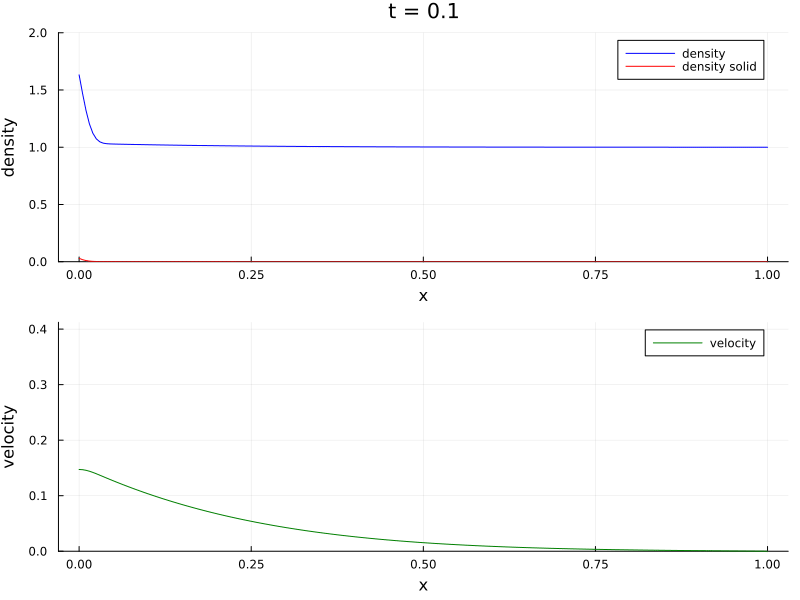

In [19]:
# double gif plot
foldername = name
sol_v = u_all[v_global, :]
sol_ρ = u_all[rho_global, :]
sol_ρ_s = u_all[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

vmax = maximum(sol_v)
vmin = minimum(sol_v)

anim = @animate for k in 1:size(sol_ρ, 2)

    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label="density",
        color=:blue,
        xlabel="x",
        ylabel="density",
        title="t = $(round(discrete_t[k], digits=3))",
        ylims=(0, ρmax),
        legend=:topright
    )

    plot!(
        p1,
        discrete_x,
        sol_ρ_s[:, k],
        label="density solid",
        color=:red,
    )

    p2 = plot(
        discrete_x,
        sol_v[:, k],
        label="velocity",
        color=:green,
        xlabel="x",
        ylabel="velocity",
        ylims=(vmin, vmax),
        legend=:topright
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end

gif(anim, joinpath(foldername, "flow_higher_def2_koekeloesen.gif"), fps=10)

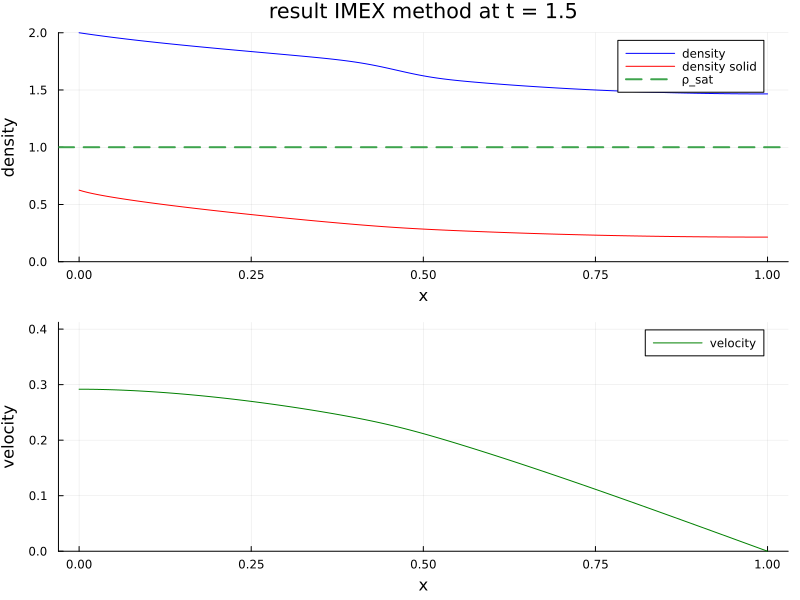

In [22]:
k = 15

# top plot: density + total pressure
p1 = plot(
    discrete_x,
    sol_ρ[:, k],
    label="density",
    color=:blue,
    xlabel="x",
    ylabel="density",
    title="result IMEX method at t = $(round(discrete_t[k], digits=3))",
    ylims=(0, ρmax),
    legend=:topright
)

plot!(
    p1,
    discrete_x,
    sol_ρ_s[:, k],
    label="density solid",
    color=:red,
)

p2 = plot(
    discrete_x,
    sol_v[:, k],
    label="velocity",
    color=:green,
    xlabel="x",
    ylabel="velocity",
    ylims=(vmin, vmax),
    legend=:topright
)

hline!(p1, 
    [rho_sat],
    label = "ρ_sat",
    lw = 2,
    # color = :green,
    linestyle = :dash)

plot(p1, p2, layout=(2,1), size=(800,600))

In [23]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "model_4_result_IMEX.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_4_result_IMEX.png"

### Ugly plots below

# Debugging

In [ ]:
# debugging
doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v, facetvalues, left, dh)

In [18]:
# debugging
display(Matrix(M_rho[rho_global, rho_global]))
display(Matrix(D[v_global, v_global]))
display(Matrix(P[
    v_global ,
    rho_global
    ]))
display(Matrix(M_v[v_global, v_global]))

201×201 Matrix{Float64}:
 0.00166667   0.000833333  0.0          …  0.0          0.0
 0.000833333  0.00333333   0.000833333     0.0          0.0
 0.0          0.000833333  0.00333333      0.0          0.0
 0.0          0.0          0.000833333     0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0             0.0          0.0
 ⋮                                      ⋱               ⋮
 0.0          0.0          0.0             0.0          0.0
 0.0          0.0          0.0          …  0.0          0.0
 0.0          0.0

201×201 Matrix{Float64}:
 -200.0   200.0     0.0     0.0     0.0  …     0.0     0.0     0.0     0.0
  200.0  -400.0   200.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0   200.0  -400.0   200.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0   200.0  -400.0   200.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0   200.0  -400.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0   200.0  …     0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0  …     0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0
    0.0     0.0     0.0     0.0     0.0        0.0     0.0     0.0     0.0


201×201 Matrix{Float64}:
 5.0  -5.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 5.0   0.0  -5.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   5.0  -8.88178e-16  -5.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   5.0           8.88178e-16      0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           5.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0          …   0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0              0.0   0.0   0.0   0.0   0.0   0.0
 0.0   0.0   0.0           0.0         

201×201 Matrix{Float64}:
 0.00333333  0.00166667  0.0         …  0.0         0.0         0.0
 0.00166667  0.00666666  0.00166666     0.0         0.0         0.0
 0.0         0.00166666  0.00666664     0.0         0.0         0.0
 0.0         0.0         0.00166666     0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0         …  0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0         …  0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 ⋮                                   ⋱                          ⋮
 0.0         0.0         

In [ ]:
# debugging

# --------------------------------------------------
# Assemble constant matrices
# --------------------------------------------------
M_rho = allocate_matrix(dh)
M_v   = allocate_matrix(dh)
D     = allocate_matrix(dh)
P     = allocate_matrix(dh)

doassemble_M_rho!(M_rho, cellvalues_rho, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)

A_lin = -P - D + M_rho/dt
B_lin = M_rho/dt

# --------------------------------------------------
# Initial condition
# --------------------------------------------------
ndofs_total = ndofs(dh)

u   = zeros(ndofs_total)
rhs = zeros(ndofs_total)
N   = zeros(ndofs_total)

apply_analytical!(u, dh, :rho, x -> 1.0)
apply_analytical!(u, dh, :v,   x -> 0.0)

update!(ch, 0.0)
apply!(u, ch)

println("Initial u:")
display(u)

# --------------------------------------------------
# Assemble nonlinear pieces at IC
# --------------------------------------------------
fill!(M_v, 0.0)
fill!(N, 0.0)

doassemble_M_v!(M_v, u, cellvalues_rho, cellvalues_v, dh)
doassemble_N!(N, u, cellvalues_rho, cellvalues_v,
              facetvalues, left, dh)

println("||N|| = ", norm(N))

# --------------------------------------------------
# Build system
# --------------------------------------------------
A = copy(A_lin)
B = copy(B_lin)

A .+= M_v/dt
B .+= M_v/dt

rhs .= B*u + N

println("norm(rhs) = ", norm(rhs))

# --------------------------------------------------
# Apply BCs
# --------------------------------------------------
update!(ch, dt)

rhsdata = get_rhs_data(ch, A)

A_bc   = copy(A)
rhs_bc = copy(rhs)

apply!(A_bc, ch)
apply_rhs!(rhsdata, rhs_bc, ch)

# --------------------------------------------------
# Diagnostics
# --------------------------------------------------
println("size(A) = ", size(A_bc))
println("rank estimate = ", rank(Matrix(A_bc)))

println("minimum diag(A) = ", minimum(diag(A_bc)))
println("maximum diag(A) = ", maximum(diag(A_bc)))

# --------------------------------------------------
# Solve ONE timestep
# --------------------------------------------------
u_new = A_bc \ rhs_bc

apply!(u_new, ch)

println("max |u_new-u| = ", maximum(abs.(u_new .- u)))

# --------------------------------------------------
# Check fields separately
# --------------------------------------------------
println("rho old:")
display(u[rho_global])

println("rho new:")
display(u_new[rho_global])

println("v old:")
display(u[v_global])

println("v new:")
display(u_new[v_global])